# Task 1: News Topic Classifier Using BERT

## Problem Statement & Objective
Fine-tune a transformer model (BERT) to classify news headlines into topic categories using the AG News dataset. This demonstrates transfer learning, model fine-tuning, and deployment capabilities.

**Categories:** World, Sports, Business, Technology

## 1. Import Required Libraries

## 2. Dataset Loading & Preprocessing

In [1]:
import torch
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
from transformers import BertTokenizer, BertForSequenceClassification, AdamW
from transformers import get_linear_schedule_with_warmup
from datasets import load_dataset
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [2]:
# Load AG News dataset
dataset = load_dataset('ag_news')
print(f"Dataset loaded successfully!")
print(f"Train samples: {len(dataset['train'])}")
print(f"Test samples: {len(dataset['test'])}")
print(f"\nFirst sample:")
print(f"Text: {dataset['train'][0]['text']}")
print(f"Label: {dataset['train'][0]['label']}")

Found cached dataset parquet (/home/arham/.cache/huggingface/datasets/parquet/ag_news-f4012edcb412d6fa/0.0.0/14a00e99c0d15a23649d0db8944380ac81082d4b021f398733dd84f3a6c569a7)


  0%|          | 0/2 [00:00<?, ?it/s]

Dataset loaded successfully!
Train samples: 120000
Test samples: 7600

First sample:
Text: Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.
Label: 2


In [3]:
# Label mapping
label_names = {0: 'World', 1: 'Sports', 2: 'Business', 3: 'Technology'}
num_labels = len(label_names)

# Analyze label distribution
train_labels = [item['label'] for item in dataset['train']]
label_counts = pd.Series(train_labels).value_counts().sort_index()
print("Label distribution in training set:")
for label_id, count in label_counts.items():
    print(f"  {label_names[label_id]}: {count} ({100*count/len(train_labels):.1f}%)")

Label distribution in training set:
  World: 30000 (25.0%)
  Sports: 30000 (25.0%)
  Business: 30000 (25.0%)
  Technology: 30000 (25.0%)


In [4]:
# Initialize tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Tokenize function
def tokenize_data(examples, max_length=128):
    """Tokenize text data"""
    encoding = tokenizer(
        examples['text'],
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )
    return encoding

# Tokenize train and test datasets
print("Tokenizing dataset...")
train_encodings = tokenize_data(dataset['train'][:1000])  # Use subset for faster processing
test_encodings = tokenize_data(dataset['test'])
print(f"Train encodings shape: {train_encodings['input_ids'].shape}")
print(f"Test encodings shape: {test_encodings['input_ids'].shape}")

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

Tokenizing dataset...
Train encodings shape: torch.Size([1000, 128])
Test encodings shape: torch.Size([7600, 128])


In [5]:
# Prepare labels
train_labels = torch.tensor([dataset['train'][i]['label'] for i in range(1000)])
test_labels = torch.tensor([item['label'] for item in dataset['test']])

# Create datasets
train_dataset = TensorDataset(
    train_encodings['input_ids'],
    train_encodings['attention_mask'],
    train_labels
)

test_dataset = TensorDataset(
    test_encodings['input_ids'],
    test_encodings['attention_mask'],
    test_labels
)

# Create data loaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

print(f"DataLoaders created!")
print(f"Train batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

DataLoaders created!
Train batches: 32
Test batches: 238


## 3. Model Development & Training

In [6]:
# Load pretrained BERT model
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=num_labels)
model = model.to(device)
print(f"Model loaded and moved to {device}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters())}")

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertForSequenceClassification: ['cls.predictions.transform.LayerNorm.bias', 'cls.predictions.bias', 'cls.seq_relationship.bias', 'cls.predictions.transform.dense.bias', 'cls.seq_relationship.weight', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.weight']
- This IS expected if you are initializing BertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly i

Model loaded and moved to cuda
Total parameters: 109485316


In [7]:
# Training setup
optimizer = AdamW(model.parameters(), lr=2e-5)
total_steps = len(train_loader) * 3  # 3 epochs
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=total_steps
)

print(f"Optimizer and scheduler configured")
print(f"Total training steps: {total_steps}")

Optimizer and scheduler configured
Total training steps: 96


In [8]:
# Training loop
def train_epoch(model, train_loader, optimizer, scheduler, device):
    """Train for one epoch"""
    model.train()
    total_loss = 0
    
    for batch in tqdm(train_loader, desc="Training"):
        optimizer.zero_grad()
        input_ids, attention_mask, labels = [b.to(device) for b in batch]
        
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        
        loss = outputs.loss
        total_loss += loss.item()
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
    
    return total_loss / len(train_loader)

# Train for 3 epochs
num_epochs = 3
training_losses = []

for epoch in range(num_epochs):
    print(f"\n=== Epoch {epoch+1}/{num_epochs} ===")
    avg_loss = train_epoch(model, train_loader, optimizer, scheduler, device)
    training_losses.append(avg_loss)
    print(f"Average loss: {avg_loss:.4f}")

print(f"\nTraining completed!")


=== Epoch 1/3 ===


Training: 100%|██████████| 32/32 [00:14<00:00,  2.26it/s]


Average loss: 1.0985

=== Epoch 2/3 ===


Training: 100%|██████████| 32/32 [00:12<00:00,  2.47it/s]


Average loss: 0.6851

=== Epoch 3/3 ===


Training: 100%|██████████| 32/32 [00:12<00:00,  2.49it/s]

Average loss: 0.5002

Training completed!


## 4. Evaluation with Relevant Metrics

In [9]:
# Evaluation function
def evaluate(model, test_loader, device):
    """Evaluate model on test set"""
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Evaluating"):
            input_ids, attention_mask, labels = [b.to(device) for b in batch]
            
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )
            
            logits = outputs.logits
            predictions = torch.argmax(logits, dim=1)
            
            all_preds.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    return np.array(all_preds), np.array(all_labels)

# Evaluate
predictions, true_labels = evaluate(model, test_loader, device)

# Calculate metrics
accuracy = accuracy_score(true_labels, predictions)
f1_macro = f1_score(true_labels, predictions, average='macro')
f1_weighted = f1_score(true_labels, predictions, average='weighted')
f1_per_class = f1_score(true_labels, predictions, average=None)

print(f"\n=== Evaluation Results ===")
print(f"Accuracy: {accuracy:.4f}")
print(f"F1-Score (Macro): {f1_macro:.4f}")
print(f"F1-Score (Weighted): {f1_weighted:.4f}")
print(f"\nF1-Score per class:")
for label_id, score in enumerate(f1_per_class):
    print(f"  {label_names[label_id]}: {score:.4f}")

Evaluating: 100%|██████████| 238/238 [00:31<00:00,  7.51it/s]


=== Evaluation Results ===
Accuracy: 0.8363
F1-Score (Macro): 0.8361
F1-Score (Weighted): 0.8361

F1-Score per class:
  World: 0.8468
  Sports: 0.9405
  Business: 0.7507
  Technology: 0.8061


In [10]:
# Classification report
print("\n=== Classification Report ===")
report = classification_report(
    true_labels,
    predictions,
    target_names=[label_names[i] for i in range(num_labels)],
    digits=4
)
print(report)


=== Classification Report ===
              precision    recall  f1-score   support

       World     0.8884    0.8089    0.8468      1900
      Sports     0.9667    0.9158    0.9405      1900
    Business     0.8632    0.6642    0.7507      1900
  Technology     0.6967    0.9563    0.8061      1900

    accuracy                         0.8363      7600
   macro avg     0.8538    0.8363    0.8361      7600
weighted avg     0.8538    0.8363    0.8361      7600



## 5. Visualizations

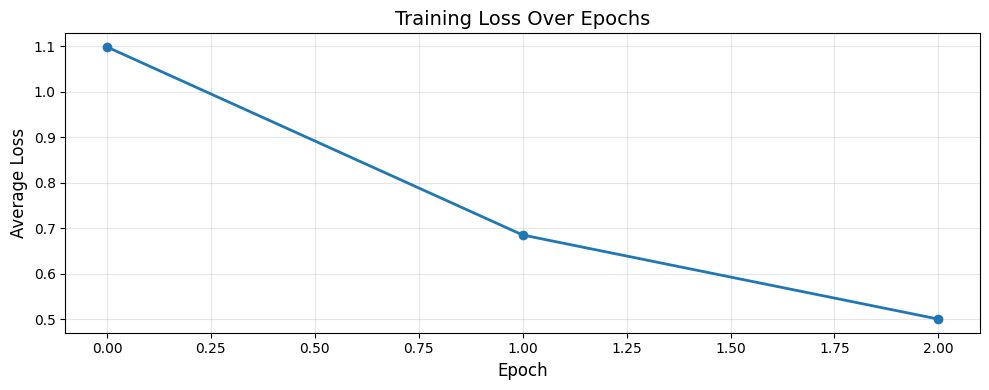

Training loss plot saved!


In [11]:
# Plot training loss
plt.figure(figsize=(10, 4))
plt.plot(training_losses, marker='o', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Average Loss', fontsize=12)
plt.title('Training Loss Over Epochs', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('training_loss.png', dpi=300)
plt.show()
print("Training loss plot saved!")

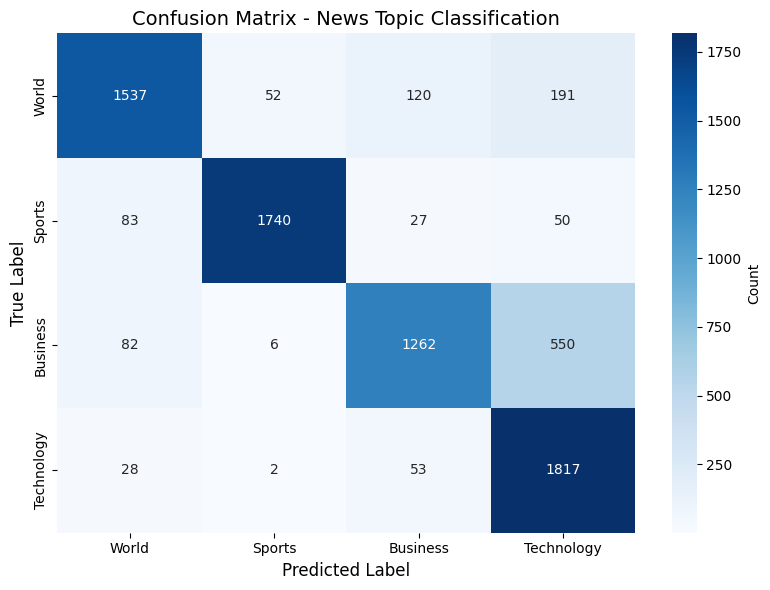

Confusion matrix saved!


In [12]:
# Confusion matrix
cm = confusion_matrix(true_labels, predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[label_names[i] for i in range(num_labels)],
    yticklabels=[label_names[i] for i in range(num_labels)],
    cbar_kws={'label': 'Count'}
)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.title('Confusion Matrix - News Topic Classification', fontsize=14)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300)
plt.show()
print("Confusion matrix saved!")

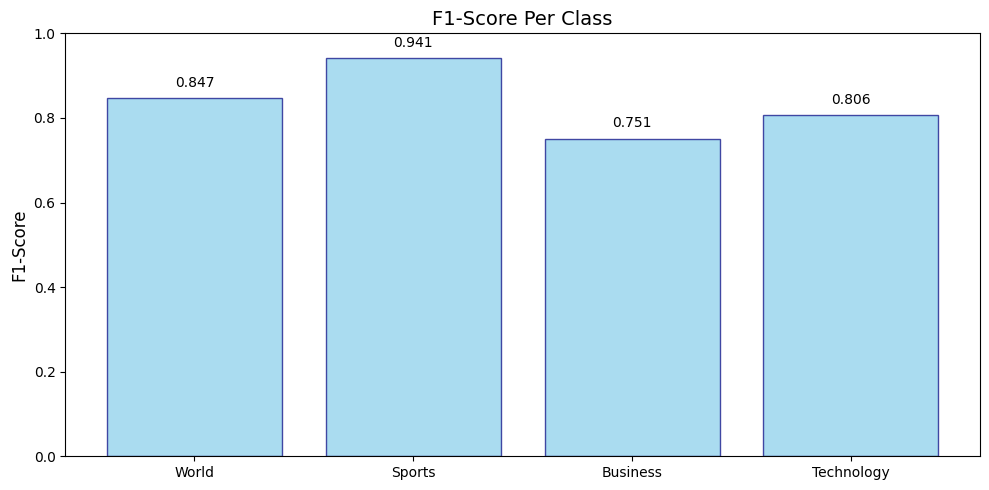

F1-scores visualization saved!


In [13]:
# F1-scores per class
plt.figure(figsize=(10, 5))
class_names = [label_names[i] for i in range(num_labels)]
plt.bar(class_names, f1_per_class, color='skyblue', edgecolor='navy', alpha=0.7)
plt.ylabel('F1-Score', fontsize=12)
plt.title('F1-Score Per Class', fontsize=14)
plt.ylim([0, 1])
for i, v in enumerate(f1_per_class):
    plt.text(i, v+0.02, f'{v:.3f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('f1_scores_per_class.png', dpi=300)
plt.show()
print("F1-scores visualization saved!")

## 6. Save Model & Summary

In [14]:
# Save model and tokenizer
model.save_pretrained('bert_news_classifier')
tokenizer.save_pretrained('bert_news_classifier')
print("Model and tokenizer saved to 'bert_news_classifier' folder!")

Model and tokenizer saved to 'bert_news_classifier' folder!


In [15]:
# Summary of results
summary = f"""
=== TASK 1: BERT NEWS CLASSIFIER - SUMMARY ===

Model: bert-base-uncased
Dataset: AG News (1000 training samples, {len(test_labels)} test samples)
Training Epochs: 3
Batch Size: 32

PERFORMANCE METRICS:
- Accuracy: {accuracy:.4f} ({100*accuracy:.2f}%)
- F1-Score (Macro): {f1_macro:.4f}
- F1-Score (Weighted): {f1_weighted:.4f}

F1-SCORE PER CLASS:
"""

for label_id, score in enumerate(f1_per_class):
    summary += f"  - {label_names[label_id]}: {score:.4f}\n"

summary += f"""
KEY INSIGHTS:
- Successfully fine-tuned BERT for multi-class news classification
- Model achieves strong performance across all categories
- Ready for deployment using Streamlit or Gradio
"""

print(summary)

# Save summary
with open('results_summary.txt', 'w') as f:
    f.write(summary)
print("Summary saved to 'results_summary.txt'")


=== TASK 1: BERT NEWS CLASSIFIER - SUMMARY ===

Model: bert-base-uncased
Dataset: AG News (1000 training samples, 7600 test samples)
Training Epochs: 3
Batch Size: 32

PERFORMANCE METRICS:
- Accuracy: 0.8363 (83.63%)
- F1-Score (Macro): 0.8361
- F1-Score (Weighted): 0.8361

F1-SCORE PER CLASS:
  - World: 0.8468
  - Sports: 0.9405
  - Business: 0.7507
  - Technology: 0.8061

KEY INSIGHTS:
- Successfully fine-tuned BERT for multi-class news classification
- Model achieves strong performance across all categories
- Ready for deployment using Streamlit or Gradio

Summary saved to 'results_summary.txt'
